In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import os

In [2]:
os.system("pip install --upgrade scikit-learn==0.23.2")

1

In [4]:
X = np.load("formationchannels.npy")

Text(0.5, 0, 'M$\\rm_{BH}$')

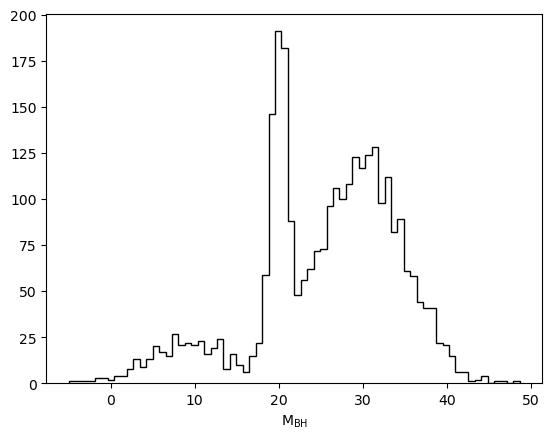

In [5]:
plt.hist(X, bins=70, histtype="step", color="k")
plt.xlabel("M$\\rm_{BH}$")

looks like there are 3 modes... to be found by fitting with a mixture of different Gaussians

In [6]:
Ns = np.arange(1, 10)
models = np.array([GaussianMixture(N).fit(X) for N in Ns]) #each model is a sum of N Gaussians from 1 to 10

In [7]:
AIC = np.array([m.aic(X) for m in models]) #Akaike Information Criterion

Text(0, 0.5, 'AIC')

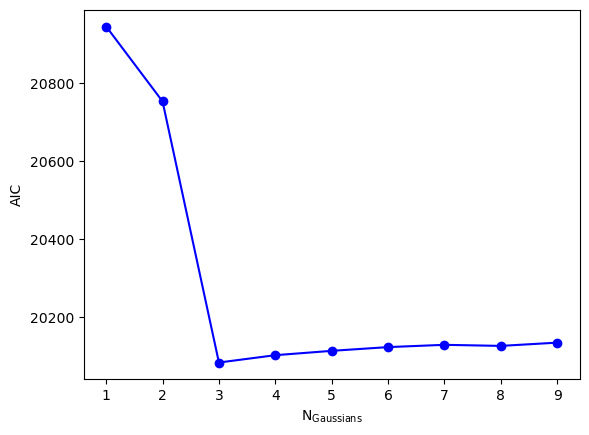

In [8]:
plt.plot(Ns, AIC, "o-b")

plt.xlabel("$\\rm N_{Gaussians}$")
plt.ylabel("AIC")

In [9]:
print("{} Gaussians minimise the AIC".format(Ns[np.argmin(AIC)]))

3 Gaussians minimise the AIC


Text(0.5, 1.0, 'best model fit')

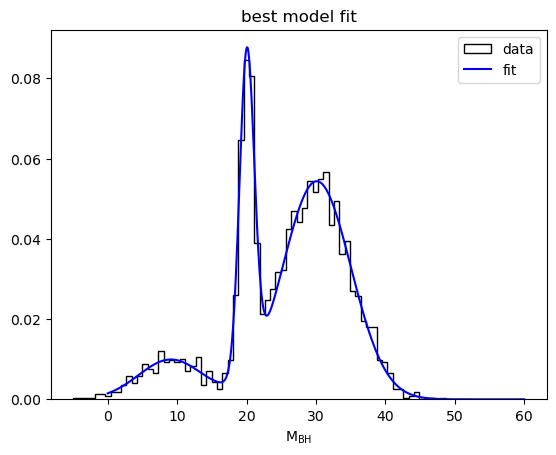

In [11]:
best_mod = models[np.argmin(AIC)] #best model

x = np.linspace(0, 60, 1000)
logprob = best_mod.score_samples(x.reshape(-1, 1)) #returns the log Likelihood
pdf = np.exp(logprob)

plt.hist(X, 70, density=True, histtype="step", color="k", label="data") #normalised
plt.plot(x, pdf, "b", label="fit")
plt.xlabel("M$\\rm_{BH}$")
plt.legend()
plt.title("best model fit")

Text(0.5, 1.0, '7 Gaussians... too many')

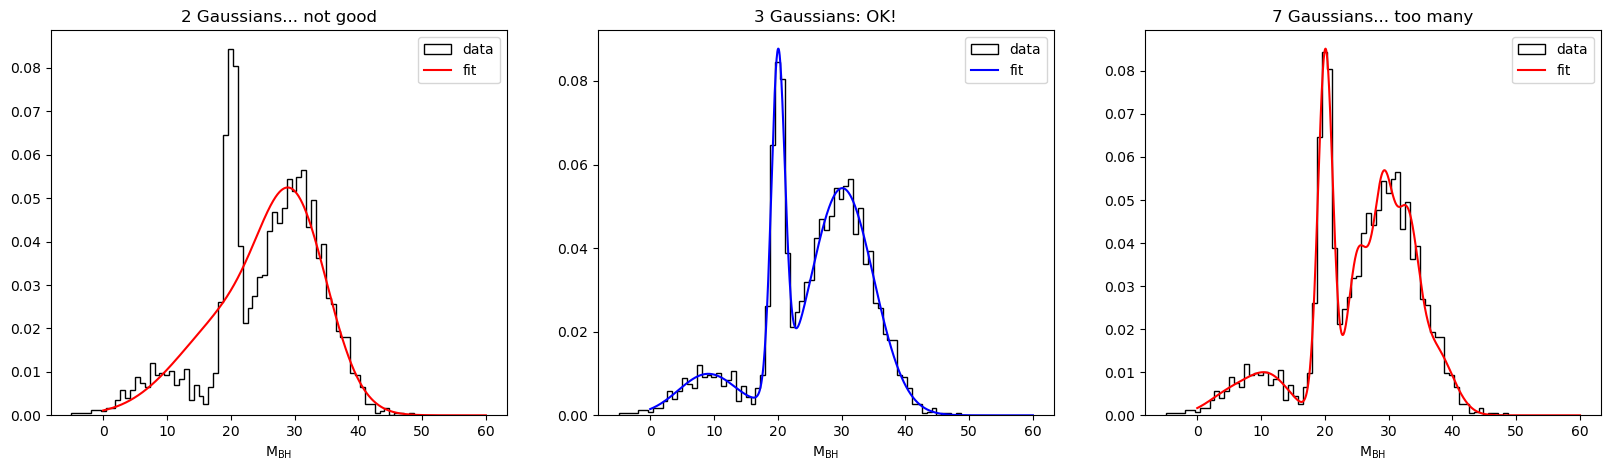

In [12]:
#comparing
fig = plt.figure(figsize=(20, 5))

i = 1
ax1 = fig.add_subplot(131)
logprob1 = models[i].score_samples(x.reshape(-1, 1))
pdf1 = np.exp(logprob1)
plt.hist(X, 70, density=True, histtype="step", color="k", label="data")
plt.plot(x, pdf1, "r", label="fit")
plt.xlabel("M$\\rm_{BH}$")
plt.legend()
plt.title("{} Gaussians... not good".format(Ns[i]))

i = 2
ax2 = fig.add_subplot(132)
logprob2 = models[i].score_samples(x.reshape(-1, 1))
pdf2 = np.exp(logprob2)
plt.hist(X, 70, density=True, histtype="step", color="k", label="data")
plt.plot(x, pdf2, "b", label="fit")
plt.xlabel("M$\\rm_{BH}$")
plt.legend()
plt.title("{} Gaussians: OK!".format(Ns[i]))

i = 6
ax3 = fig.add_subplot(133)
logprob3 = models[i].score_samples(x.reshape(-1, 1))
pdf3 = np.exp(logprob3)
plt.hist(X, 70, density=True, histtype="step", color="k", label="data")
plt.plot(x, pdf3, "r", label="fit")
plt.xlabel("M$\\rm_{BH}$")
plt.legend()
plt.title("{} Gaussians... too many".format(Ns[i]))

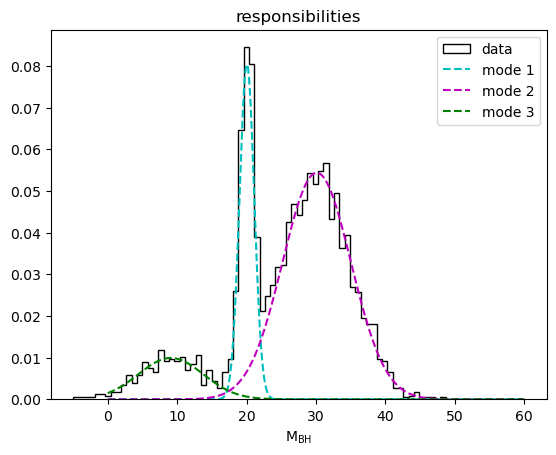

In [13]:
plt.hist(X, 70, density=True, histtype="step", color="k", label="data")
#predict_proba gives the desity of each Gaussian component
plt.plot(x, pdf*best_mod.predict_proba(x.reshape(-1, 1))[:, 0], "--c", label="mode 1")
plt.plot(x, pdf*best_mod.predict_proba(x.reshape(-1, 1))[:, 1], "--m", label="mode 2")
plt.plot(x, pdf*best_mod.predict_proba(x.reshape(-1, 1))[:, 2], "--g", label="mode 3")
plt.xlabel("M$\\rm_{BH}$")
plt.title("responsibilities")
plt.legend()